# Imports

This section loads all required libraries for the project. We use PyTorch for model building and training, torchvision for pretrained models and image transformations, and standard utilities for data handling and evaluation.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, ConcatDataset, random_split
from torchvision import datasets, transforms, models

from helper import make_dataset, train, test, get_indices
import matplotlib.pyplot as plt
import numpy as np

# Device Configuration

This section sets up the computation device. If a CUDA-enabled GPU is available, the model and tensors will be moved to GPU for faster training. Otherwise, computation will fall back to CPU.

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


# Dataset Paths

Specify the directory paths for the training and validation datasets. The dataset should follow the ImageFolder structure, where each class (e.g., `real`, `fake`) is stored in a separate subfolder.

In [3]:
import torch
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  
    transforms.RandomRotation(5),      
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_real_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\train\real"
train_fake_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\train\fake"
valid_real_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\valid\real"
valid_fake_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\valid\fake"

train_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\train"
valid_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\valid"

# Data Loading and Preprocessing

This section creates the training, validation, and test datasets using PyTorch's `ImageFolder`. It also defines image transformations such as resizing and normalization, and wraps datasets into DataLoaders for efficient batching and shuffling during training.

In [4]:

train_dataset = make_dataset(train_dir, 9500, 500, transform)

valid_dataset = make_dataset(valid_dir, 950, 50, transform)

val_size = int(0.5 * len(valid_dataset))
test_size = len(valid_dataset) - val_size

val_dataset, test_dataset = random_split(valid_dataset, [val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

real_count = 0
fake_count = 0

for _, labels in train_loader:
    real_count += (labels == 0).sum().item()
    fake_count += (labels == 1).sum().item()

print("Train real:", real_count)
print("Train fake:", fake_count)



Train real: 9500
Train fake: 500


# Model: ResNet18 (Transfer Learning)

We use a pretrained ResNet18 model as the backbone. The final fully connected layer is replaced to adapt the model for binary classification (real vs fake). Selective layer unfreezing is applied to fine-tune higher-level features while retaining pretrained representations.

In [5]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(128, 32),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(32, 2),
)
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer2.parameters():
    param.requires_grad = True

## Configure the loss, optimizer, scheduler, and start training

This cell defines the main training setup.

- **Loss:** `CrossEntropyLoss` with class weights `[1.0, 19.0]` to penalize mistakes on fake images more heavily.
- **Optimizer:** Adam with **different learning rates** for different parts of the network.
  - `layer3` and `layer4` use a smaller learning rate because they come from the pretrained backbone.
  - `fc` uses a larger learning rate because it is newly initialized and must learn from scratch.
- **Scheduler:** `ReduceLROnPlateau` lowers the learning rate when validation performance stops improving.
- **Training:** the model is trained for **20 epochs**.

The cell also stores the loss values and thresholds returned by the training function, and extracts the best threshold from the recorded values.


In [6]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0,19.0]).to(device))
model = model.to(device)
optimizer = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.layer4.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-4, 'weight_decay': 1e-4}
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)
loss_values, thresholds = train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=20, scheduler=scheduler)
best_epoch_idx = thresholds.index(max(thresholds, key=lambda t: t))  # or manually note it
best_threshold = thresholds[best_epoch_idx]
# test(model, test_loader, device, threshold=best_threshold)


Epoch : 0
Optimal Threshold : 0.4412
Train Loss        : 0.6845
F1 Score          : 0.1875
Recall            : 0.2903  <- how many anomalies caught
Precision         : 0.1385
AUC-ROC           : 0.6256
PR-AUC            : 0.1482

Confusion Matrix:
                   Predicted Real  Predicted Fake
Actual Real        413             56
Actual Fake        22              9

Epoch : 1
Optimal Threshold : 0.4116
Train Loss        : 0.6732
F1 Score          : 0.1864
Recall            : 0.3548  <- how many anomalies caught
Precision         : 0.1264
AUC-ROC           : 0.6681
PR-AUC            : 0.1415

Confusion Matrix:
                   Predicted Real  Predicted Fake
Actual Real        393             76
Actual Fake        20              11

Epoch : 2
Optimal Threshold : 0.4815
Train Loss        : 0.6457
F1 Score          : 0.4062
Recall            : 0.4194  <- how many anomalies caught
Precision         : 0.3939
AUC-ROC           : 0.8399
PR-AUC            : 0.3904

Confusion Matrix:
  

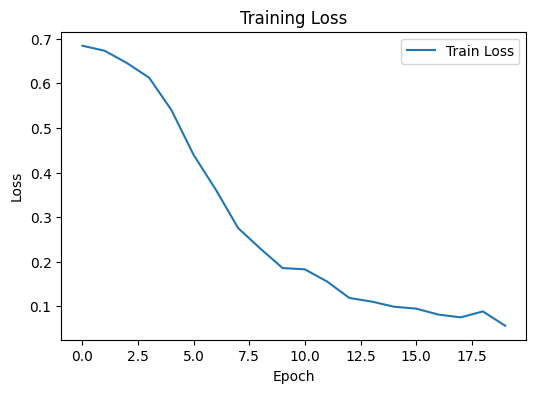

C:\Users\thoai\AppData\Local\Temp\ipykernel_14300\2632336927.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


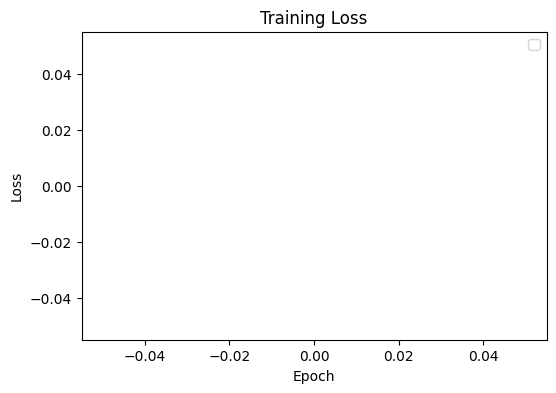

In [7]:
# Remove the accuracy plot, just plot loss
plt.figure(figsize=(6, 4))
plt.plot(loss_values, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('training_loss.png')
plt.show()

# Remove the accuracy plot, just plot loss
plt.figure(figsize=(6, 4))
plt.plot(label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('training_loss.png')
plt.show()

## Load the best saved model and evaluate threshold sensitivity

This final cell reloads the saved checkpoint (`best_model.pth`) and evaluates the model on the held-out test set. The `test(...)` function is used with `threshold=None`, which means it searches over thresholds and returns:
- the best threshold found on the test set,
- the F1 score values across thresholds, and
- the threshold grid used for the search.

The plot then visualizes **F1 score versus classification threshold** and marks the threshold that gives the best F1.

C:\Users\thoai\AppData\Local\Temp\ipykernel_14300\3181151988.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


(Optimal threshold computed from test data: 0.8190)

TEST SET RESULTS (Threshold: 0.8190)
F1 Score          : 0.7429
Recall            : 0.6842  <- how many anomalies caught
Precision         : 0.8125
AUC-ROC           : 0.9099
PR-AUC            : 0.7417

Confusion Matrix:
                   Predicted Real  Predicted Fake
Actual Real        478             3
Actual Fake        6               13


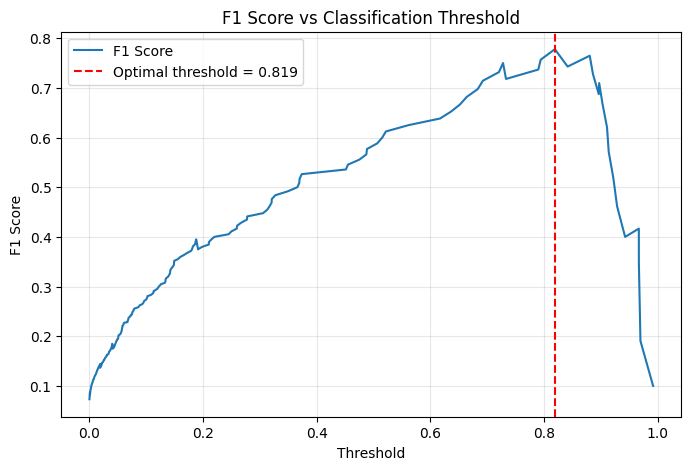

In [11]:
from sklearn.metrics import average_precision_score
from helper import make_dataset, train, test, get_indices

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model = model.to(device)

# test(model, test_loader, device, threshold=None)

# Cell 8: NEW - Threshold vs F1 plot
all_labels = []
all_probs = []
best_test_threshold, f1_scores, thresholds_curve = test(model, test_loader, device, threshold=None)

plt.figure(figsize=(8, 5))
plt.plot(thresholds_curve, f1_scores[:-1], label='F1 Score')
plt.axvline(x=best_test_threshold, color='r', linestyle='--', label=f'Optimal threshold = {best_test_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Classification Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('threshold_vs_f1.png', dpi=150)
plt.show()